In [1]:
import os

import numpy as np
import torch
import torch.nn as nn

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

/scratch/users/maulmer/miniforge3/envs/pyro/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# random simulation of data
# simulate high-dimensional data coming from a mixture of Gaussians
def simulate_data(num_samples=1000, num_features=10, num_components=3, scale_factor=5):
    # Generate random means and covariances for the mixture components
    means = [scale_factor * torch.randn(num_features) for _ in range(num_components)]
    covariances = [torch.eye(num_features) for _ in range(num_components)]

    # Generate random weights for the mixture components
    weights = torch.ones(num_components) / num_components

    # Sample from the mixture of Gaussians
    component_indices = torch.multinomial(weights, num_samples, replacement=True)
    data = torch.stack([dist.MultivariateNormal(means[i], covariance_matrix=covariances[i]).sample()
                        for i in component_indices])

    return data, component_indices


In [3]:
# sample data
num_samples = 10000
num_features = 8
num_components = 2
data, component_indices = simulate_data(num_samples, num_features, num_components)

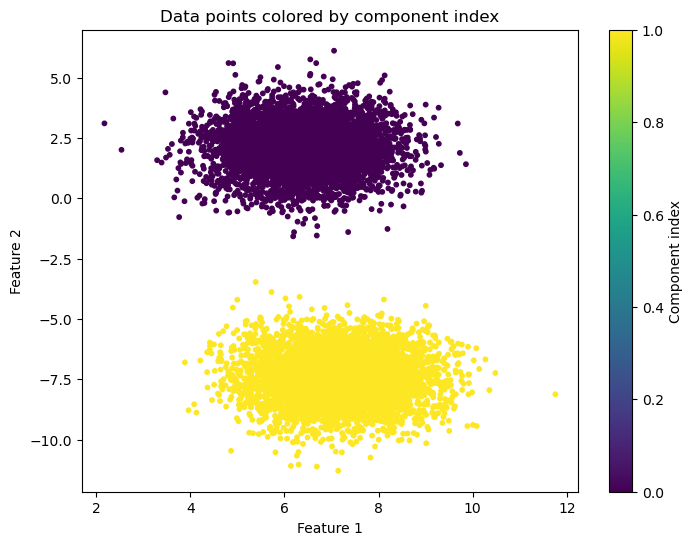

In [4]:
# plot data 
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0].cpu().numpy(), data[:, 1].cpu().numpy(), c=component_indices.cpu().numpy(), cmap='viridis', s=10)
plt.title('Data points colored by component index')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Component index')
plt.show()

In [5]:
# setup data loaders
def setup_data_loaders(batch_size=64, use_cuda=False):
    # create a train and test from data
    train_data = data[:int(0.8 * num_samples)]
    test_data = data[int(0.8 * num_samples):]
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False)
    if use_cuda:
        train_loader = [(x.cuda(),) for x in train_loader]
        test_loader = [(x.cuda(),) for x in test_loader]
    return train_loader, test_loader

In [6]:
class Decoder(nn.Module):
    def __init__(self, z_dim, hidden_dim):
        super().__init__()
        # setup the two linear transformations used
        self.fc1 = nn.Linear(z_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, num_features)
        self.fc22 = nn.Linear(hidden_dim, num_features)
        # setup the non-linearities
        self.softplus = nn.Softplus()
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        # define the forward computation on the latent z
        # first compute the hidden units
        hidden = self.softplus(self.fc1(z))
        # return the parameter for the output Bernoulli
        # each is of size batch_size x 784
        loc_img = self.sigmoid(self.fc21(hidden))
        scale_img = torch.exp(self.fc22(hidden))
        return loc_img, scale_img

class Encoder(nn.Module):
    def __init__(self, z_dim, hidden_dim):
        super().__init__()
        # setup the three linear transformations used
        self.fc1 = nn.Linear(num_features, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, z_dim)
        self.fc22 = nn.Linear(hidden_dim, z_dim)
        # setup the non-linearities
        self.softplus = nn.Softplus()

    def forward(self, x):
        # define the forward computation on the image x
        # first shape the mini-batch to have pixels in the rightmost dimension
        x = x.reshape(-1, num_features)
        # then compute the hidden units
        hidden = self.softplus(self.fc1(x))
        # then return a mean vector and a (positive) square root covariance
        # each of size batch_size x z_dim
        z_loc = self.fc21(hidden)
        z_scale = torch.exp(self.fc22(hidden))
        return z_loc, z_scale

In [7]:
class VAE(nn.Module):
    # by default our latent space is 50-dimensional
    # and we use 400 hidden units
    def __init__(self, z_dim=2, hidden_dim=400, use_cuda=False):
        super().__init__()
        # create the encoder and decoder networks
        self.encoder = Encoder(z_dim, hidden_dim)
        self.decoder = Decoder(z_dim, hidden_dim)

        if use_cuda:
            # calling cuda() here will put all the parameters of
            # the encoder and decoder networks into gpu memory
            self.cuda()
        self.use_cuda = use_cuda
        self.z_dim = z_dim

    # define the model p(x|z)p(z)
    def model(self, x):
        # register PyTorch module `decoder` with Pyro
        pyro.module("decoder", self.decoder)
        with pyro.plate("data", x.shape[0]):
            # setup hyperparameters for prior p(z)
            z_loc = x.new_zeros(torch.Size((x.shape[0], self.z_dim)))
            z_scale = x.new_ones(torch.Size((x.shape[0], self.z_dim)))
            # sample from prior (value will be sampled by guide when computing the ELBO)
            z = pyro.sample("latent", dist.Normal(z_loc, z_scale).to_event(1))
            # decode the latent code z
            loc_img, scale_img = self.decoder(z)
            # score against actual images
            pyro.sample("obs", dist.Normal(loc_img, scale_img).to_event(1), obs=x.reshape(-1, num_features))

    # define the guide (i.e. variational distribution) q(z|x)
    def guide(self, x):
        # register PyTorch module `encoder` with Pyro
        pyro.module("encoder", self.encoder)
        with pyro.plate("data", x.shape[0]):
            # use the encoder to get the parameters used to define q(z|x)
            z_loc, z_scale = self.encoder(x)
            # sample the latent code z
            pyro.sample("latent", dist.Normal(z_loc, z_scale).to_event(1))

    # define a helper function for reconstructing images
    def reconstruct_img(self, x):
        # encode image x
        z_loc, z_scale = self.encoder(x)
        # sample in latent space
        z = dist.Normal(z_loc, z_scale).sample()
        # decode the image (note we don't sample in image space)
        loc_img = self.decoder(z)
        return loc_img

In [8]:
def train(svi, train_loader, use_cuda=False):
    # initialize loss accumulator
    epoch_loss = 0.
    # do a training epoch over each mini-batch x returned
    # by the data loader
    for x in train_loader:
        # if on GPU put mini-batch into CUDA memory
        if use_cuda:
            x = x.cuda()
        # do ELBO gradient and accumulate loss
        epoch_loss += svi.step(x)

    # return epoch loss
    normalizer_train = len(train_loader.dataset)
    total_epoch_loss_train = epoch_loss / normalizer_train
    return total_epoch_loss_train

def evaluate(svi, test_loader, use_cuda=False):
    # initialize loss accumulator
    test_loss = 0.
    # compute the loss over the entire test set
    for x in test_loader:
        # if on GPU put mini-batch into CUDA memory
        if use_cuda:
            x = x.cuda()
        # compute ELBO estimate and accumulate loss
        test_loss += svi.evaluate_loss(x)
    normalizer_test = len(test_loader.dataset)
    total_epoch_loss_test = test_loss / normalizer_test
    return total_epoch_loss_test

In [9]:
# Run options
LEARNING_RATE = 1.0e-5
USE_CUDA = False

# Run only for a single iteration for testing
NUM_EPOCHS = 500
TEST_FREQUENCY = 5

In [142]:
train_loader, test_loader = setup_data_loaders(batch_size=256, use_cuda=USE_CUDA)

# clear param store
pyro.clear_param_store()

# setup the VAE
vae = VAE(use_cuda=USE_CUDA)

# setup the optimizer
adam_args = {"lr": LEARNING_RATE}
optimizer = Adam(adam_args)

# setup the inference algorithm
svi = SVI(vae.model, vae.guide, optimizer, loss=Trace_ELBO())

train_elbo = []
test_elbo = []
# training loop
for epoch in range(NUM_EPOCHS):
    total_epoch_loss_train = train(svi, train_loader, use_cuda=USE_CUDA)
    train_elbo.append(-total_epoch_loss_train)
    print("[epoch %03d]  average training loss: %.4f" % (epoch, total_epoch_loss_train))

    if epoch % TEST_FREQUENCY == 0:
        # report test diagnostics
        total_epoch_loss_test = evaluate(svi, test_loader, use_cuda=USE_CUDA)
        test_elbo.append(-total_epoch_loss_test)
        print("[epoch %03d] average test loss: %.4f" % (epoch, total_epoch_loss_test))

[epoch 000]  average training loss: 74.2098
[epoch 000] average test loss: 65.2072
[epoch 001]  average training loss: 58.5735
[epoch 002]  average training loss: 49.9737
[epoch 003]  average training loss: 43.4724
[epoch 004]  average training loss: 39.2986
[epoch 005]  average training loss: 36.0680
[epoch 005] average test loss: 34.8367
[epoch 006]  average training loss: 33.5192
[epoch 007]  average training loss: 31.5001
[epoch 008]  average training loss: 30.0481
[epoch 009]  average training loss: 28.7538
[epoch 010]  average training loss: 27.6520
[epoch 010] average test loss: 27.3354
[epoch 011]  average training loss: 26.8231
[epoch 012]  average training loss: 26.1425
[epoch 013]  average training loss: 25.4634
[epoch 014]  average training loss: 24.9234
[epoch 015]  average training loss: 24.5302
[epoch 015] average test loss: 24.3820
[epoch 016]  average training loss: 24.1258
[epoch 017]  average training loss: 23.8331
[epoch 018]  average training loss: 23.4928
[epoch 0

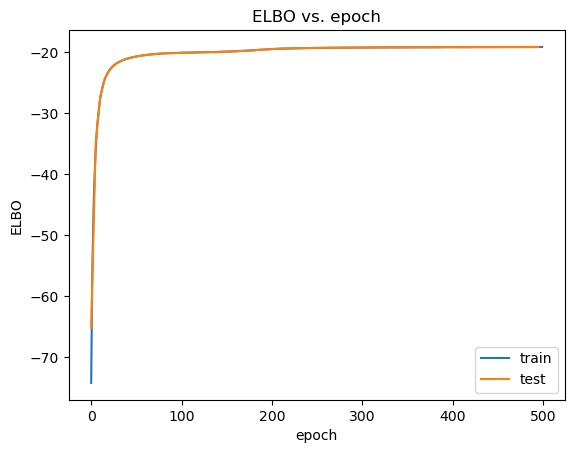

In [143]:
# plot the training and test ELBO
train_epochs = np.arange(len(train_elbo))
test_epochs = np.arange(len(test_elbo)) * TEST_FREQUENCY

import matplotlib.pyplot as plt
plt.plot(train_epochs, train_elbo, label='train')
plt.plot(test_epochs, test_elbo, label='test')
plt.xlabel('epoch')
plt.ylabel('ELBO')
plt.title('ELBO vs. epoch')
plt.legend()
plt.show()

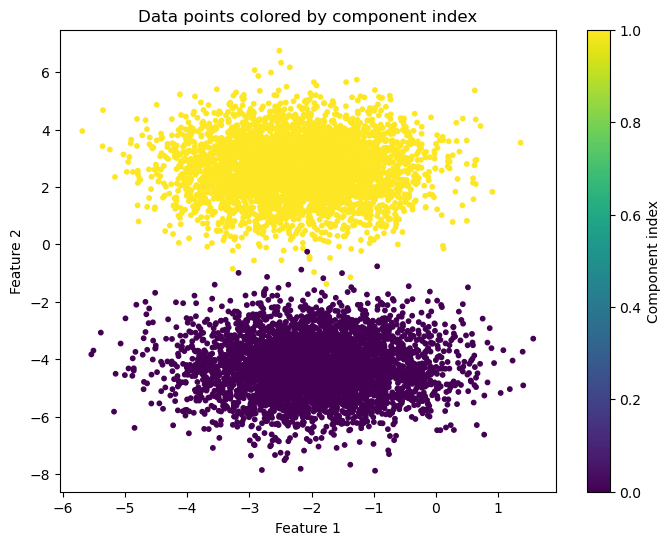

In [144]:
# plot data 
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(data[:int(0.8 * num_samples), 0].cpu().numpy(), data[:int(0.8 * num_samples), 1].cpu().numpy(), c=component_indices[:int(0.8 * num_samples)].cpu().numpy(), cmap='viridis', s=10)
plt.title('Data points colored by component index')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Component index')
plt.show()

In [145]:
# get posterior of latents given data
def get_latents(vae, data):
    # encode data
    z_loc, z_scale = vae.encoder(data)
    # sample in latent space
    z = dist.Normal(z_loc, z_scale).sample()
    return z
# get the latents for the training data
train_latents = get_latents(vae, data)
# plot the latents
train_latents

tensor([[-0.8513, -1.4636],
        [ 1.3389,  1.4623],
        [ 0.5314, -0.1031],
        ...,
        [-0.2865,  0.5749],
        [-0.7520,  1.5246],
        [-1.0064,  0.2964]])

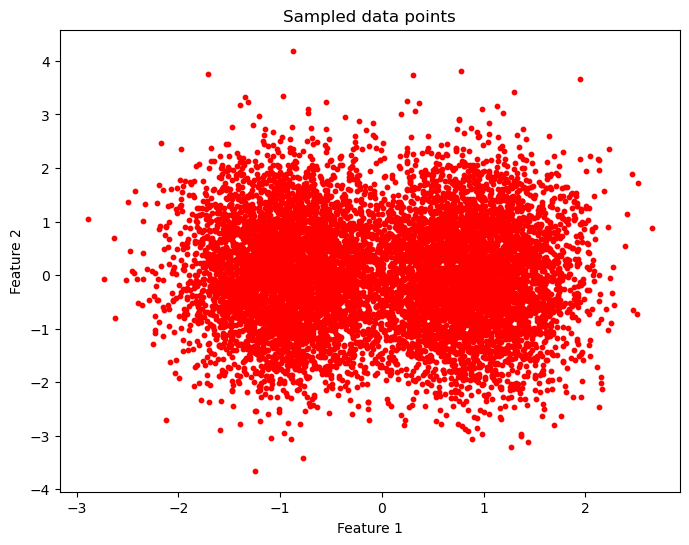

In [146]:
plt.figure(figsize=(8, 6))
plt.scatter(train_latents[:, 0].detach().numpy(), train_latents[:, 1].detach().numpy(), c='red', s=10)
plt.title('Sampled data points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [147]:
    loc_img, scale_img = vae.decoder(train_latents)
    # sample from the decoder p(x|z)
    x_sample = dist.Normal(loc_img, scale_img).sample()

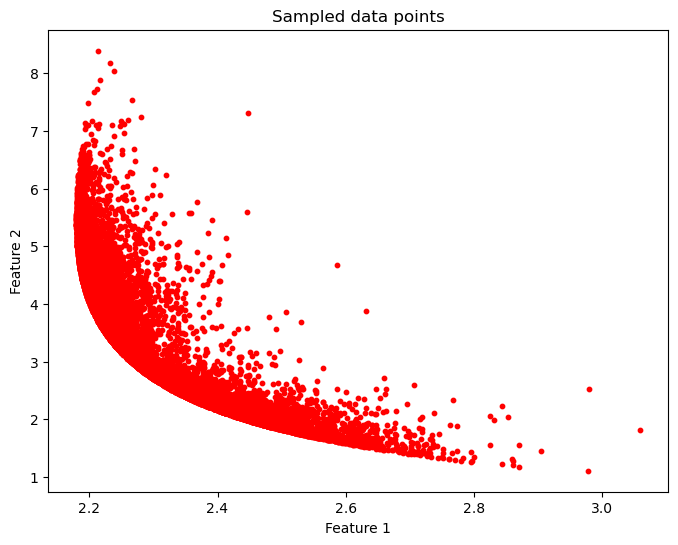

In [149]:
plt.figure(figsize=(8, 6))
plt.scatter(scale_img[:, 0].detach().numpy(), scale_img[:, 1].detach().numpy(), c='red', s=10)
plt.title('Sampled data points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()